In [ ]:
# Import necessary libraries for data manipulation and visualization
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings

# --- Settings for Publication-Quality Plots ---
plt.style.use('seaborn-v0_8-whitegrid')
plt.rcParams.update({'font.size': 12, 'axes.titlesize': 14, 'axes.labelsize': 12})
warnings.filterwarnings('ignore')


In [ ]:
from google.colab import files
print("Please upload the 'delhi_air_quality_hourly.csv' file.")
uploaded = files.upload()

file_name = list(uploaded.keys())[0]
df = pd.read_csv(file_name)

print("\nDataset loaded successfully. Here are the first 5 rows:")
print(df.head())


Please upload the 'delhi_air_quality_hourly.csv' file.


Saving delhi_air_quality_hourly.csv to delhi_air_quality_hourly (2).csv

Dataset loaded successfully. Here are the first 5 rows:
        Datetime   PM2.5    PM10     NO    NO2     NOx    NH3     CO   SO2  \
0  1/1/2015 1:00  454.58  935.18  81.52  41.78  187.66  27.54   9.29  3.41   
1  1/1/2015 5:00  415.88  976.99  60.24  37.41   80.12  30.84  26.19  6.17   
2  1/1/2015 6:00  384.16  862.23  59.84  32.06   78.34  30.71  11.04  7.33   
3  1/1/2015 7:00  344.44  731.83  66.55  30.97   84.67  30.64   8.39  8.00   
4  1/1/2015 8:00  337.98  725.74  72.93  26.83   90.44  28.10   7.89  9.00   

      O3  Benzene  Toluene  Xylene  
0  54.94    25.24    58.57   13.80  
1  16.00    11.14    21.99   14.29  
2  12.33    10.70    20.85   12.42  
3  58.67    10.15    19.80   10.35  
4  13.42    11.53    21.53   10.24  


In [ ]:
df['Datetime'] = pd.to_datetime(df['Datetime'])
df.set_index('Datetime', inplace=True)
df.sort_index(inplace=True)

df = df[
    ['PM2.5', 'PM10', 'NO', 'NO2', 'NOx',
     'NH3', 'CO', 'SO2', 'O3']
]

df['PM2.5'].interpolate(method='linear', inplace=True)
df.dropna(inplace=True)

print("\nData Information after Cleaning and Preparation:")
df.info()

print("\nCleaned DataFrame Head:")
print(df.head())



Data Information after Cleaning and Preparation:
<class 'pandas.core.frame.DataFrame'>
DatetimeIndex: 29086 entries, 2015-01-01 01:00:00 to 2020-07-01 00:00:00
Data columns (total 9 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   PM2.5   29086 non-null  float64
 1   PM10    29086 non-null  float64
 2   NO      29086 non-null  float64
 3   NO2     29086 non-null  float64
 4   NOx     29086 non-null  float64
 5   NH3     29086 non-null  float64
 6   CO      29086 non-null  float64
 7   SO2     29086 non-null  float64
 8   O3      29086 non-null  float64
dtypes: float64(9)
memory usage: 2.2 MB

Cleaned DataFrame Head:
                      PM2.5    PM10     NO    NO2     NOx    NH3     CO   SO2  \
Datetime                                                                        
2015-01-01 01:00:00  454.58  935.18  81.52  41.78  187.66  27.54   9.29  3.41   
2015-01-01 05:00:00  415.88  976.99  60.24  37.41   80.12  30.84  26.19  6.17   
2015-01-01 

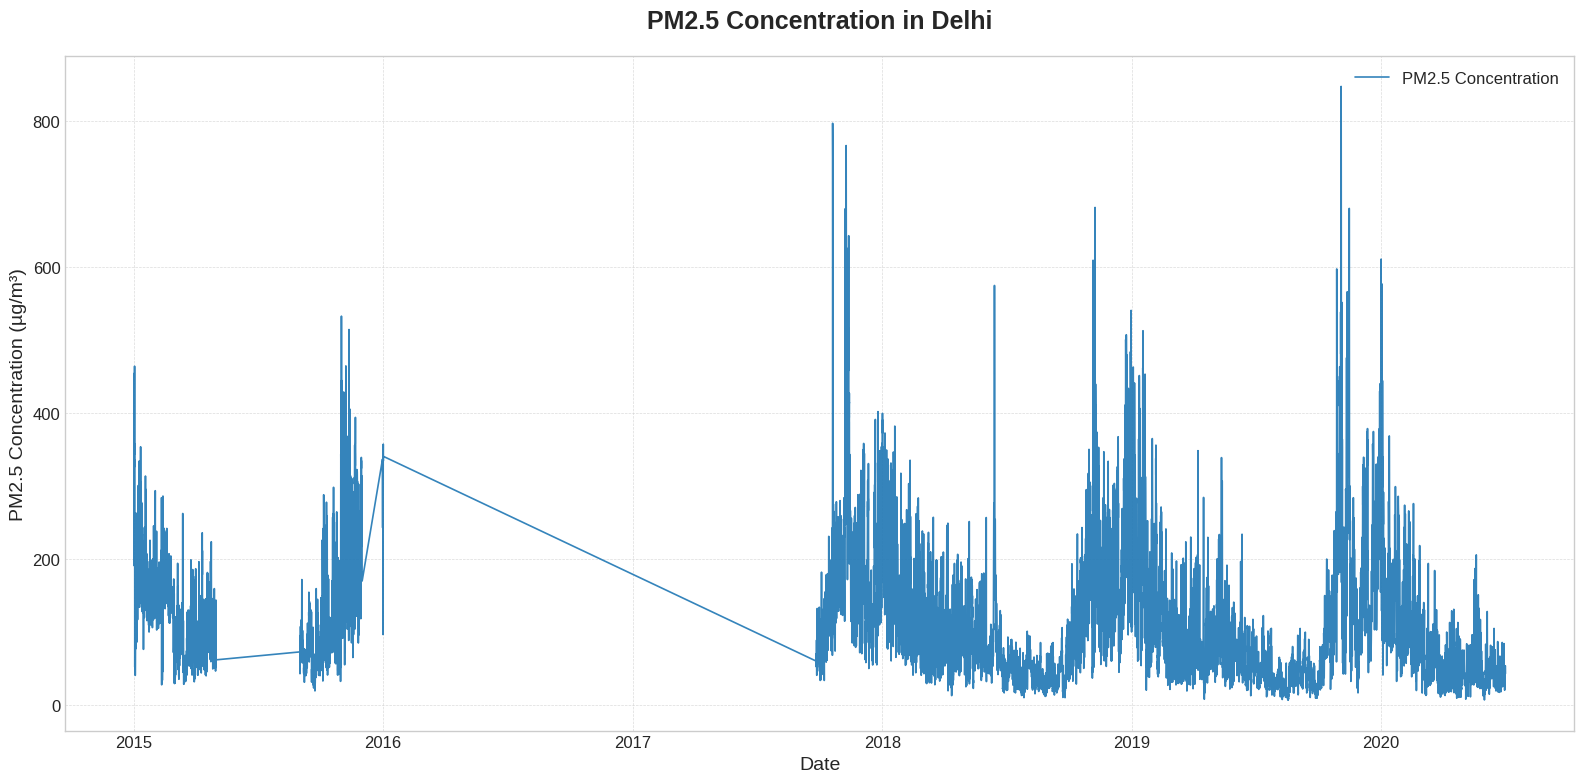

In [ ]:
plt.figure(figsize=(16, 8))
plt.plot(
    df.index,
    df['PM2.5'],
    label='PM2.5 Concentration',
    linewidth=1.2,
    alpha=0.9
)

plt.title(
    'PM2.5 Concentration in Delhi',
    fontsize=18,
    pad=20,
    fontweight='bold'
)
plt.xlabel('Date', fontsize=14)
plt.ylabel('PM2.5 Concentration (µg/m³)', fontsize=14)

plt.grid(which='both', linestyle='--', linewidth=0.5, alpha=0.7)
plt.legend(fontsize=12)
plt.tight_layout()
plt.show()


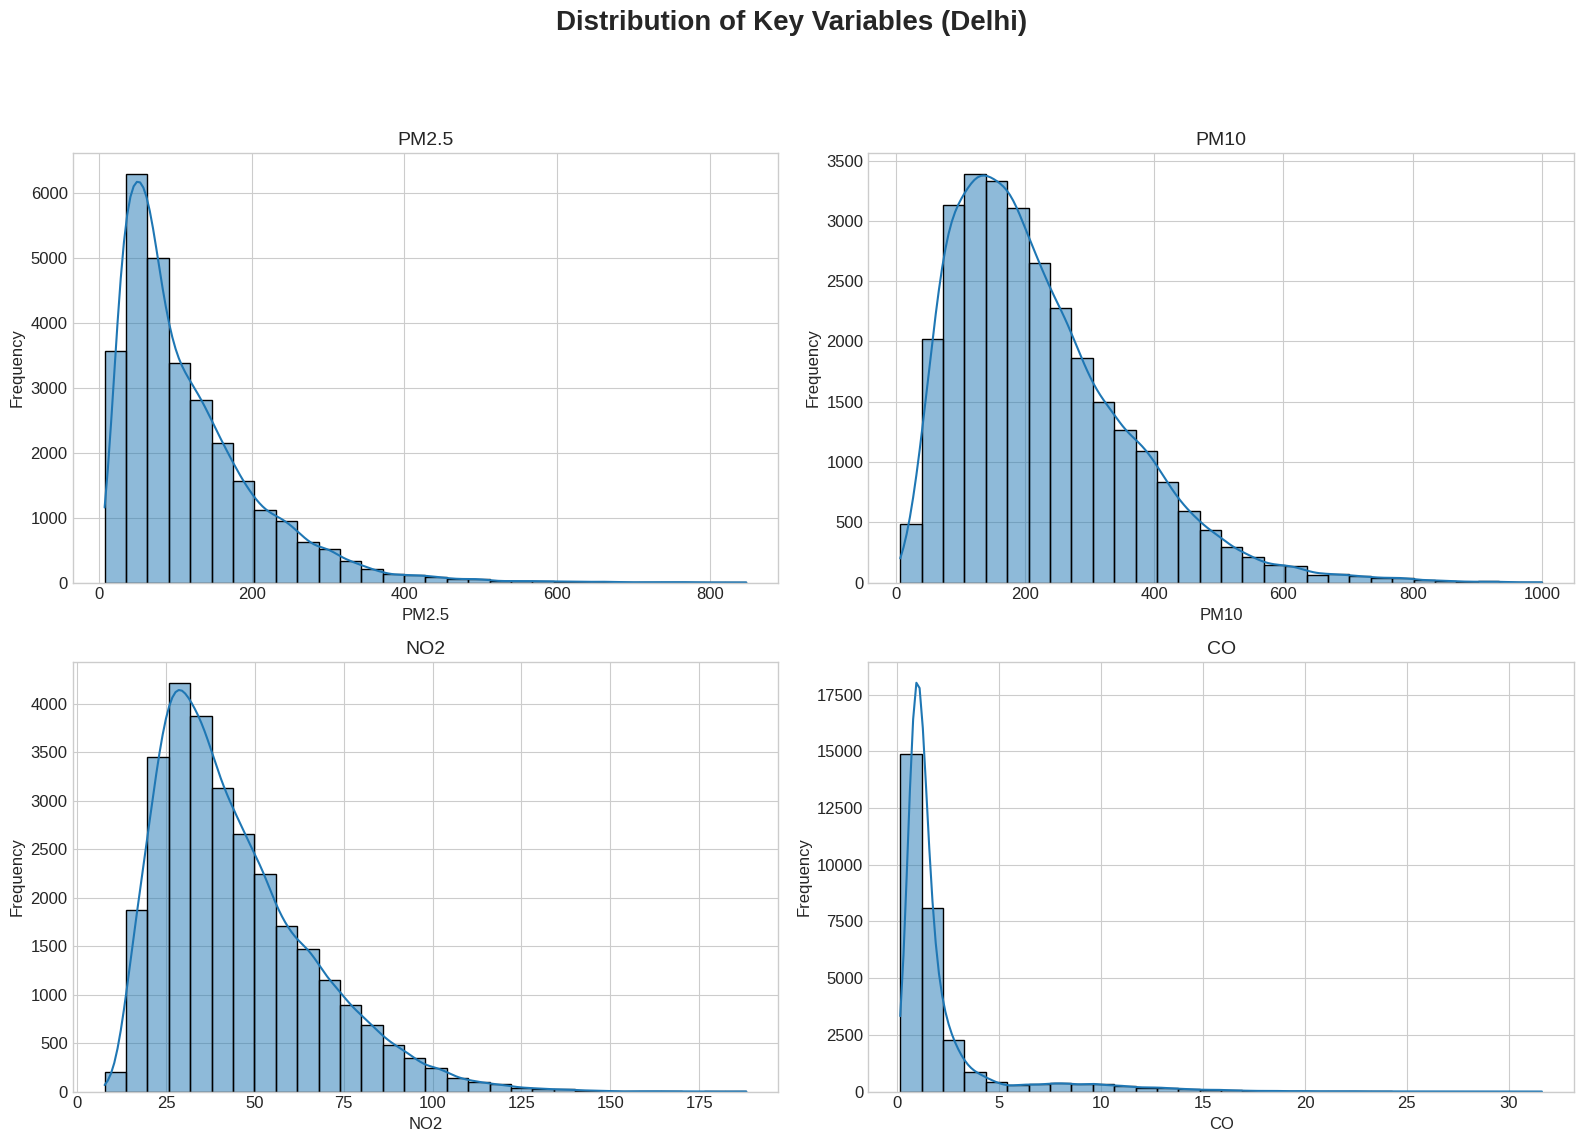

In [ ]:
fig, axes = plt.subplots(2, 2, figsize=(16, 12), facecolor='white')

fig.suptitle(
    'Distribution of Key Variables (Delhi)',
    fontsize=20,
    fontweight='bold',
    y=0.98
)

plots = [
    {'data': df['PM2.5'], 'ax': axes[0, 0], 'title': 'PM2.5'},
    {'data': df['PM10'],  'ax': axes[0, 1], 'title': 'PM10'},
    {'data': df['NO2'],   'ax': axes[1, 0], 'title': 'NO2'},
    {'data': df['CO'],    'ax': axes[1, 1], 'title': 'CO'}
]

for plot in plots:
    sns.histplot(
        plot['data'],
        kde=True,
        ax=plot['ax'],
        bins=30
    )
    plot['ax'].set_title(plot['title'])
    plot['ax'].set_xlabel(plot['title'])
    plot['ax'].set_ylabel('Frequency')

plt.tight_layout(rect=[0, 0.03, 1, 0.93])
plt.show()


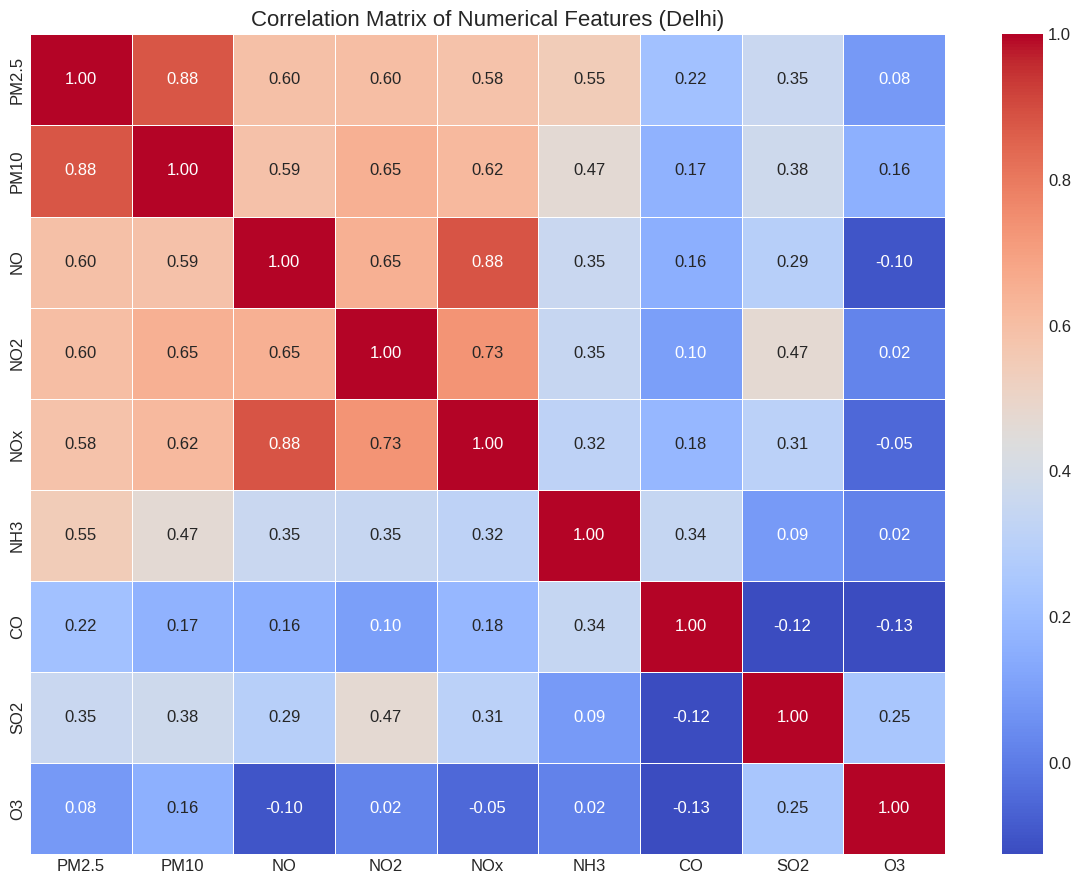

In [ ]:
numeric_df = df.select_dtypes(include=np.number)
corr_matrix = numeric_df.corr()

plt.figure(figsize=(12, 9))
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', fmt=".2f", linewidths=.5)
plt.title('Correlation Matrix of Numerical Features (Delhi)', fontsize=16)
plt.tight_layout()
plt.show()


In [ ]:
from sklearn.preprocessing import MinMaxScaler
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense, Dropout
from tensorflow.keras.callbacks import EarlyStopping


In [ ]:
scaler = MinMaxScaler()
scaled_data = scaler.fit_transform(df)

scaled_df = pd.DataFrame(
    scaled_data,
    columns=df.columns,
    index=df.index
)


In [ ]:
train_size = int(len(scaled_df) * 0.7)
val_size = int(len(scaled_df) * 0.15)

train_data = scaled_df.iloc[:train_size]
val_data = scaled_df.iloc[train_size:train_size + val_size]
test_data = scaled_df.iloc[train_size + val_size:]


In [ ]:
def create_sliding_window(data, look_back=24, target_col='PM2.5'):
    X, y = [], []
    target_col_index = data.columns.get_loc(target_col)

    for i in range(len(data) - look_back):
        X.append(data.iloc[i:i + look_back].values)
        y.append(data.iloc[i + look_back, target_col_index])

    return np.array(X), np.array(y)


In [ ]:
LOOK_BACK = 24

X_train, y_train = create_sliding_window(train_data, LOOK_BACK)
X_val, y_val = create_sliding_window(val_data, LOOK_BACK)
X_test, y_test = create_sliding_window(test_data, LOOK_BACK)


In [ ]:
X_train_rf = X_train.reshape(X_train.shape[0], -1)
X_test_rf = X_test.reshape(X_test.shape[0], -1)

rf_model = RandomForestRegressor(
    n_estimators=200,
    max_depth=15,
    min_samples_split=10,
    random_state=42,
    n_jobs=-1
)

rf_model.fit(X_train_rf, y_train)
rf_predictions_scaled = rf_model.predict(X_test_rf)


In [ ]:
dummy_pred = np.zeros((len(rf_predictions_scaled), scaled_df.shape[1]))
dummy_true = np.zeros((len(y_test), scaled_df.shape[1]))

dummy_pred[:, 0] = rf_predictions_scaled
dummy_true[:, 0] = y_test

rf_pred = scaler.inverse_transform(dummy_pred)[:, 0]
y_test_actual = scaler.inverse_transform(dummy_true)[:, 0]

print("\n--- Delhi Random Forest Performance ---")
print("MAE:", mean_absolute_error(y_test_actual, rf_pred))
print("RMSE:", np.sqrt(mean_squared_error(y_test_actual, rf_pred)))
print("R²:", r2_score(y_test_actual, rf_pred))



--- Delhi Random Forest Performance ---
MAE: 5.939824741367048
RMSE: 8.737133673590217
R²: 0.9781918558748032


In [ ]:
lstm_model = Sequential([
    LSTM(64, return_sequences=True, input_shape=(X_train.shape[1], X_train.shape[2])),
    Dropout(0.2),
    LSTM(32),
    Dropout(0.2),
    Dense(1)
])

lstm_model.compile(optimizer='adam', loss='mean_squared_error')

early_stopping = EarlyStopping(monitor='val_loss', patience=5, restore_best_weights=True)

history = lstm_model.fit(
    X_train, y_train,
    validation_data=(X_val, y_val),
    epochs=50,
    batch_size=64,
    callbacks=[early_stopping],
    verbose=1
)


Epoch 1/50
318/318 ━━━━━━━━━━━━━━━━━━━━ 16s 34ms/step - loss: 0.0058 - val_loss: 0.0020
Epoch 2/50
318/318 ━━━━━━━━━━━━━━━━━━━━ 11s 33ms/step - loss: 0.0018 - val_loss: 9.1843e-04
Epoch 3/50
318/318 ━━━━━━━━━━━━━━━━━━━━ 11s 35ms/step - loss: 0.0012 - val_loss: 6.5995e-04
Epoch 4/50
318/318 ━━━━━━━━━━━━━━━━━━━━ 10s 30ms/step - loss: 9.1657e-04 - val_loss: 4.9372e-04
Epoch 5/50
318/318 ━━━━━━━━━━━━━━━━━━━━ 11s 32ms/step - loss: 8.3842e-04 - val_loss: 3.5763e-04
Epoch 6/50
318/318 ━━━━━━━━━━━━━━━━━━━━ 11s 33ms/step - loss: 7.8199e-04 - val_loss: 3.5010e-04
Epoch 7/50
318/318 ━━━━━━━━━━━━━━━━━━━━ 12s 37ms/step - loss: 7.0954e-04 - val_loss: 3.3504e-04
Epoch 8/50
318/318 ━━━━━━━━━━━━━━━━━━━━ 11s 35ms/step - loss: 6.3910e-04 - val_loss: 2.6942e-04
Epoch 9/50
318/318 ━━━━━━━━━━━━━━━━━━━━ 11s 34ms/step - loss: 6.4276e-04 - val_loss: 2.3617e-04
Epoch 10/50
318/318 ━━━━━━━━━━━━━━━━━━━━ 10s 31ms/step - loss: 5.9634e-04 - val_loss: 2.3534e-04
Epoch 11/50
318/318 ━━━━━━━━━━━━━━━━━━━━ 11s 32ms/step 

In [ ]:
# --- LSTM Predictions ---
lstm_predictions_scaled = lstm_model.predict(X_test)

# --- Inverse Scaling ---
dummy_pred_lstm = np.zeros((len(lstm_predictions_scaled), scaled_df.shape[1]))
dummy_pred_lstm[:, 0] = lstm_predictions_scaled.flatten()

lstm_predictions_actual = scaler.inverse_transform(dummy_pred_lstm)[:, 0]

# --- LSTM Performance Metrics ---
print("\n--- Delhi LSTM Performance ---")
print("MAE:", mean_absolute_error(y_test_actual, lstm_predictions_actual))
print("RMSE:", np.sqrt(mean_squared_error(y_test_actual, lstm_predictions_actual)))
print("R²:", r2_score(y_test_actual, lstm_predictions_actual))


136/136 ━━━━━━━━━━━━━━━━━━━━ 6s 37ms/step

--- Delhi LSTM Performance ---
MAE: 6.4439226899708055
RMSE: 9.010906258832744
R²: 0.9768037547619235


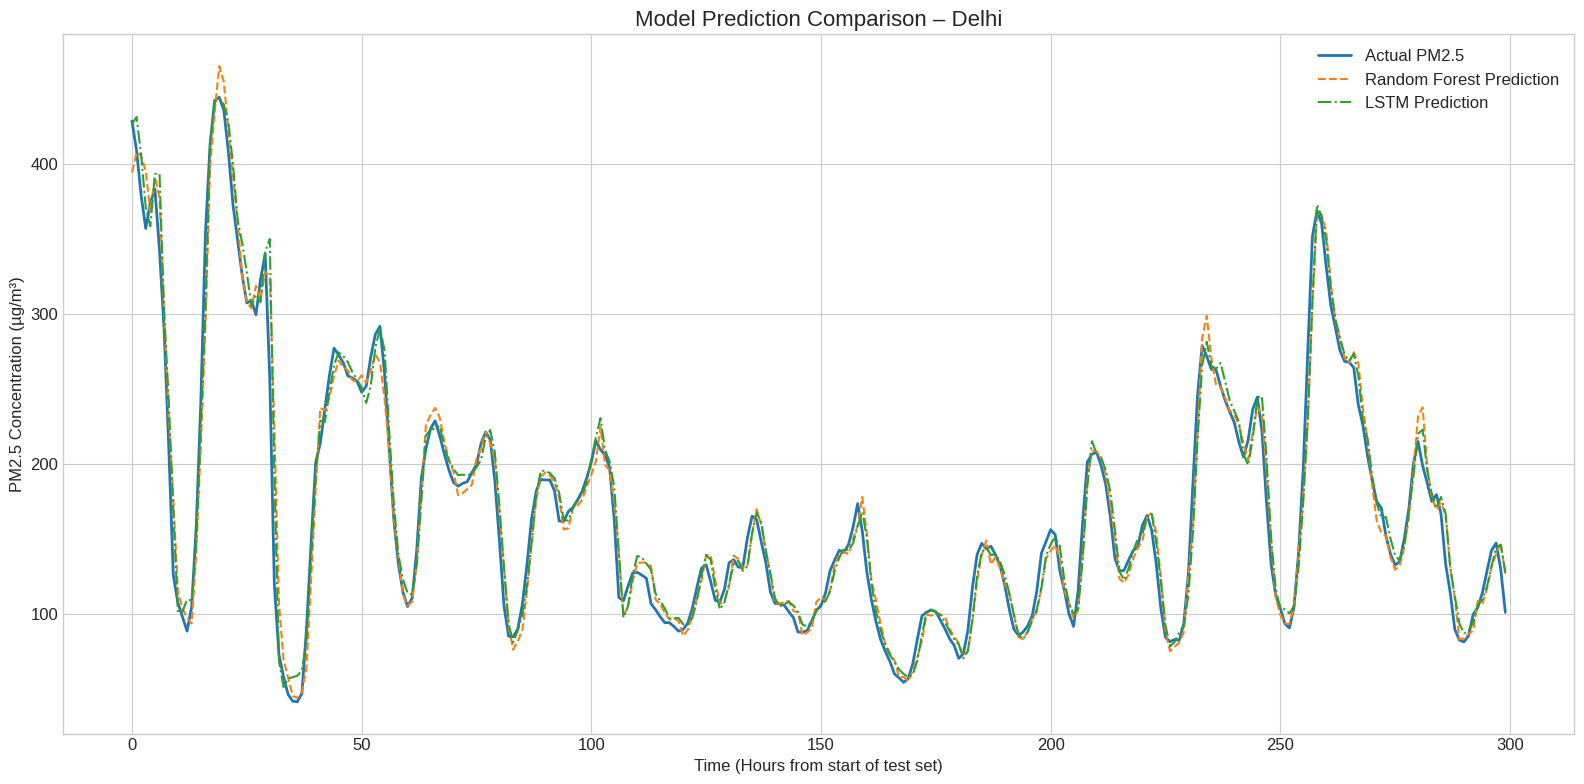

In [ ]:
plt.figure(figsize=(16, 8))

plt.plot(
    y_test_actual[:300],
    label='Actual PM2.5',
    linewidth=2
)

plt.plot(
    rf_pred[:300],
    label='Random Forest Prediction',
    linestyle='--'
)

plt.plot(
    lstm_predictions_actual[:300],
    label='LSTM Prediction',
    linestyle='-.'
)

plt.title(
    'Model Prediction Comparison – Delhi',
    fontsize=16
)
plt.xlabel('Time (Hours from start of test set)')
plt.ylabel('PM2.5 Concentration (µg/m³)')
plt.legend()
plt.tight_layout()
plt.show()
